In [2]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [3]:
# information about the dataset
df =  pd.read_csv("D:\projects\Smart_cart_clustring\smartcart_customers (1).csv")
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\acer\AppData\Local\Temp\ipykernel_11120\193680330.py:2: SyntaxWarning: invalid escape sequence '\p'
  df =  pd.read_csv("D:\projects\Smart_cart_clustring\smartcart_customers (1).csv")


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.009375,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.096391,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000


In [4]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
columns_to_impute = ["Income","MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
x = df[columns_to_impute].values
x_imputed = imputer.fit_transform(x)


In [5]:
df["Income"] = x_imputed[:, 0]
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [6]:
#feature_engineering
df["total_spent"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]
df["total_purchases"] = df[["NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]].sum(axis=1)
df["AGE"] = 2026 - df["Year_Birth"]
df["tenure"] = (pd.to_datetime("01-03-2026") - pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")).dt.days


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [8]:
df = df[df["AGE"] <= 90]

<Axes: xlabel='Income', ylabel='Count'>

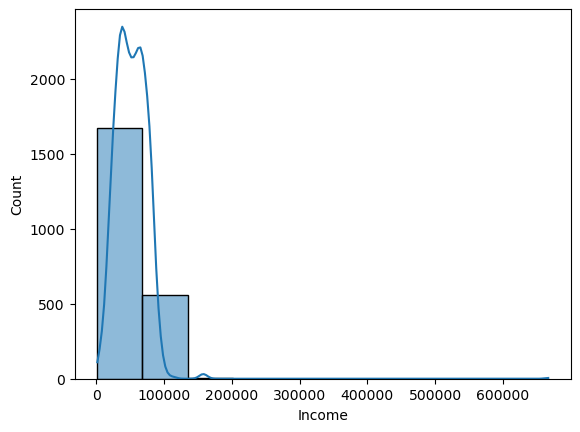

In [9]:
sns.histplot(df["Income"], bins = 10, kde = True)

Skewness BEFORE transformation:
Income              6.74
MntWines            1.18
MntFruits           2.10
MntMeatProducts     2.09
MntFishProducts     1.92
MntSweetProducts    2.14
MntGoldProds        1.89
total_purchases     0.25
dtype: float64

Skewness AFTER transformation:
Income_log             -1.16
MntWines_log           -0.55
MntFruits_log           0.08
MntMeatProducts_log    -0.08
MntFishProducts_log    -0.05
MntSweetProducts_log    0.09
MntGoldProds_log       -0.34
total_purchases_log    -0.58
dtype: float64


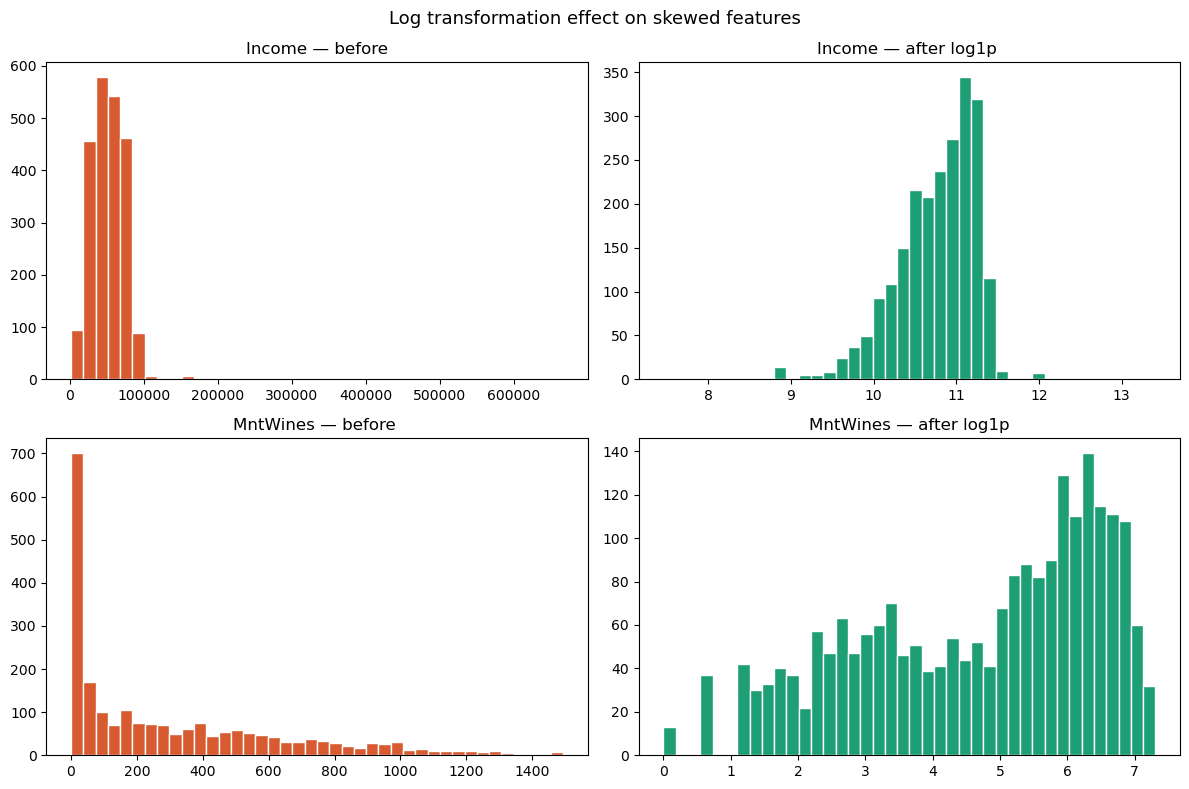

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# --- Check skewness BEFORE ---
spend_cols = ['Income', 'MntWines', 'MntFruits',
              'MntMeatProducts', 'MntFishProducts',
              'MntSweetProducts', 'MntGoldProds', 'total_purchases']

print("Skewness BEFORE transformation:")
print(df[spend_cols].skew().round(2))

for col in spend_cols:
    df[col + '_log'] = np.log1p(df[col])

log_cols = [c + '_log' for c in spend_cols]
print("\nSkewness AFTER transformation:")
print(df[log_cols].skew().round(2))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].hist(df['Income'], bins=40, color='#D85A30', edgecolor='white')
axes[0,0].set_title('Income — before')

axes[0,1].hist(df['Income_log'], bins=40, color='#1D9E75', edgecolor='white')
axes[0,1].set_title('Income — after log1p ')

axes[1,0].hist(df['MntWines'], bins=40, color='#D85A30', edgecolor='white')
axes[1,0].set_title('MntWines — before ')

axes[1,1].hist(df['MntWines_log'], bins=40, color='#1D9E75', edgecolor='white')
axes[1,1].set_title('MntWines — after log1p')

plt.suptitle('Log transformation effect on skewed features', fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AGE,tenure,Income_log,MntWines_log,MntFruits_log,MntMeatProducts_log,MntFishProducts_log,MntSweetProducts_log,MntGoldProds_log,total_purchases_log
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,69,4869,10.970592,6.455199,4.488636,6.304449,5.153292,4.488636,4.488636,3.258097
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,72,4319,10.743869,2.484907,0.693147,1.945910,1.098612,0.693147,1.945910,1.945910
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,61,4518,11.179046,6.056784,3.912023,4.852030,4.718499,3.091042,3.761200,3.091042
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,42,4345,10.190432,2.484907,1.609438,3.044522,2.397895,1.386294,1.791759,2.197225
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,45,4367,10.973254,5.159055,3.784190,4.779123,3.850148,3.332205,2.772589,2.995732


In [12]:
df["Education"].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

In [13]:
#encoding
#label encoding for education
Graduation_mapping = {"Basic": 0, "2n Cycle": 1, "Graduation": 1, "Master": 2, "PhD": 3}
df["education_encoded"] = df["Education"].replace(Graduation_mapping)

#one-hot encoding for Marital_Status
marital_dummies = pd.get_dummies(df["Marital_Status"],prefix="Marital",drop_first = True,dtype = int)
df = pd.concat([df,marital_dummies],axis = 1)
df.head()


C:\Users\acer\AppData\Local\Temp\ipykernel_11120\3868654405.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["education_encoded"] = df["Education"].replace(Graduation_mapping)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds_log,total_purchases_log,education_encoded,Marital_Alone,Marital_Divorced,Marital_Married,Marital_Single,Marital_Together,Marital_Widow,Marital_YOLO
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,4.488636,3.258097,1,0,0,0,1,0,0,0
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1.945910,1.945910,1,0,0,0,1,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,3.761200,3.091042,1,0,0,0,0,1,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,1.791759,2.197225,1,0,0,0,0,1,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,2.772589,2.995732,3,0,0,1,0,0,0,0


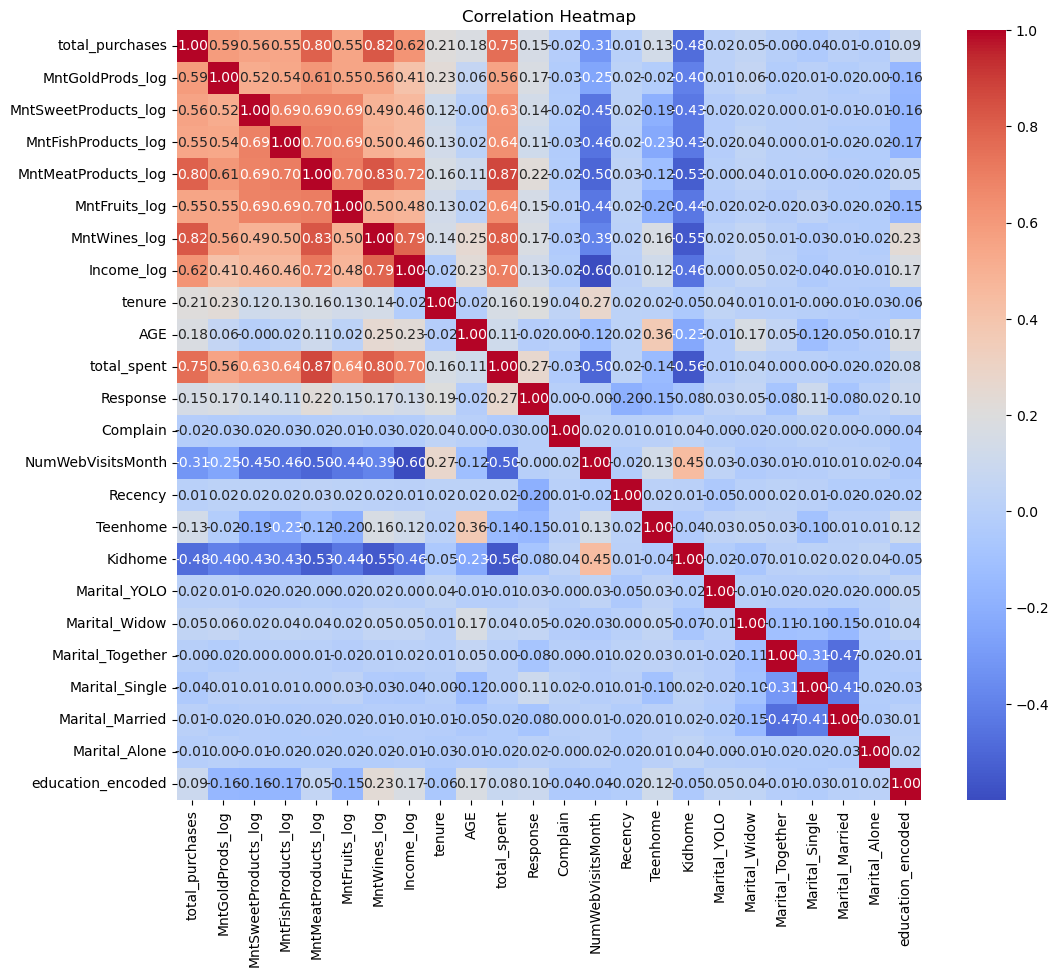

In [14]:
corr_columns = ["total_purchases","MntGoldProds_log","MntSweetProducts_log","MntFishProducts_log","MntMeatProducts_log","MntFruits_log","MntWines_log","Income_log","tenure","AGE","total_spent","Response","Complain","NumWebVisitsMonth","Recency","Teenhome","Kidhome","Marital_YOLO","Marital_Widow","Marital_Together","Marital_Single","Marital_Married","Marital_Alone","education_encoded",]
df_corr = df[corr_columns].corr()
plt.figure(figsize = (12,10))
sns.heatmap(df_corr,annot=True,cmap = "coolwarm",fmt = ".2f")
plt.title("Correlation Heatmap")
plt.show()

In [15]:
x = df[corr_columns]
x.shape

(2237, 24)

In [16]:
# Data Preprocessing using StandardScaler
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()
x_scaled = Scaler.fit_transform(x)

In [17]:
# doing PCA for dimentionality reduction
from sklearn.decomposition import PCA
pca_full = PCA()
pca_full.fit(x_scaled)

PCA()

In [18]:
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)
cumulative

array([0.2869847 , 0.36888461, 0.43164927, 0.49316409, 0.54993954,
       0.59887695, 0.64409077, 0.68600064, 0.72771841, 0.76894197,
       0.80789003, 0.83728942, 0.86378424, 0.88706951, 0.9079878 ,
       0.92651877, 0.94356855, 0.95659188, 0.96908211, 0.9788443 ,
       0.98570188, 0.99176685, 0.99630196, 1.        ])

In [19]:
for i , (e,c) in enumerate(zip(explained,cumulative)):
    print(f"{i+1} explained: {e:.1%} | cumulative: {c:.1%}")

1 explained: 28.7% | cumulative: 28.7%
2 explained: 8.2% | cumulative: 36.9%
3 explained: 6.3% | cumulative: 43.2%
4 explained: 6.2% | cumulative: 49.3%
5 explained: 5.7% | cumulative: 55.0%
6 explained: 4.9% | cumulative: 59.9%
7 explained: 4.5% | cumulative: 64.4%
8 explained: 4.2% | cumulative: 68.6%
9 explained: 4.2% | cumulative: 72.8%
10 explained: 4.1% | cumulative: 76.9%
11 explained: 3.9% | cumulative: 80.8%
12 explained: 2.9% | cumulative: 83.7%
13 explained: 2.6% | cumulative: 86.4%
14 explained: 2.3% | cumulative: 88.7%
15 explained: 2.1% | cumulative: 90.8%
16 explained: 1.9% | cumulative: 92.7%
17 explained: 1.7% | cumulative: 94.4%
18 explained: 1.3% | cumulative: 95.7%
19 explained: 1.2% | cumulative: 96.9%
20 explained: 1.0% | cumulative: 97.9%
21 explained: 0.7% | cumulative: 98.6%
22 explained: 0.6% | cumulative: 99.2%
23 explained: 0.5% | cumulative: 99.6%
24 explained: 0.4% | cumulative: 100.0%


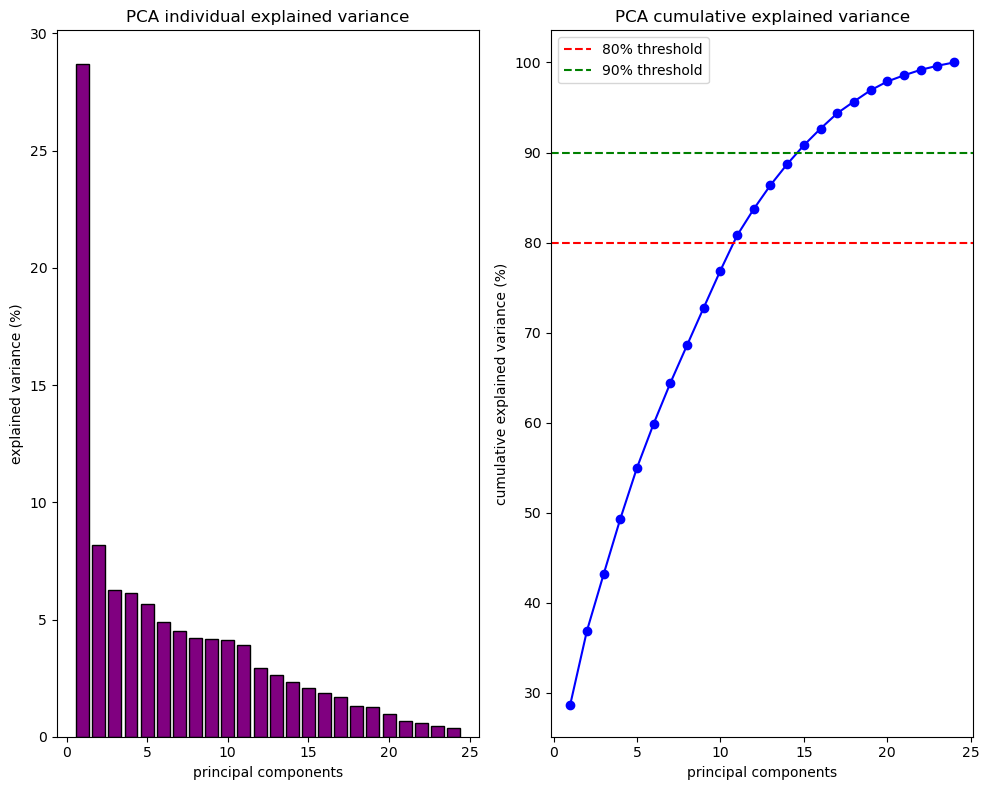

In [20]:
plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
plt.bar(range(1,len(explained)+1),explained*100,color = "purple",edgecolor = "black")
plt.xlabel("principal components")
plt.ylabel("explained variance (%)")
plt.title("PCA individual explained variance")
plt.subplot(1,2,2)
plt.plot(range(1,len(cumulative)+1),cumulative*100,color = "blue",marker = "o")
plt.xlabel("principal components")
plt.ylabel("cumulative explained variance (%)")
plt.title("PCA cumulative explained variance")
plt.axhline(y = 80,color = "red",linestyle = "--",label = "80% threshold")
plt.axhline(y = 90,color = "green",linestyle = "--",label = "90% threshold")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
loading = pd.DataFrame(
    pca_full.components_.T,
    index=corr_columns,
    columns=[f"PC{i+1}" for i in range(pca_full.n_components_)]
).round(2)
loading

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24
total_purchases,0.32,0.13,-0.02,0.15,-0.09,0.04,-0.11,0.04,-0.04,-0.01,...,-0.14,-0.04,-0.27,-0.09,0.01,-0.55,-0.53,0.01,-0.28,-0.11
MntGoldProds_log,0.27,-0.10,-0.03,0.15,-0.19,0.12,0.07,0.06,-0.06,0.09,...,-0.50,-0.22,0.66,-0.10,-0.05,0.06,0.05,-0.02,-0.04,-0.06
MntSweetProducts_log,0.29,-0.22,0.04,-0.08,-0.08,0.01,0.07,0.02,-0.00,0.05,...,0.01,0.45,-0.10,-0.65,-0.37,0.19,0.02,-0.01,-0.01,0.06
MntFishProducts_log,0.29,-0.22,0.03,-0.09,-0.08,0.02,0.10,-0.00,0.00,0.04,...,-0.01,0.18,0.02,0.03,0.83,0.16,-0.05,-0.00,-0.07,0.07
MntMeatProducts_log,0.36,-0.02,-0.00,0.03,0.01,-0.03,-0.07,-0.01,-0.01,-0.05,...,0.00,-0.10,-0.15,0.04,0.02,-0.05,0.13,0.08,0.71,-0.53
MntFruits_log,0.30,-0.21,0.03,-0.06,-0.07,0.03,0.06,0.01,0.02,0.04,...,-0.05,0.33,0.06,0.73,-0.37,-0.03,-0.04,0.03,-0.05,0.09
MntWines_log,0.33,0.23,-0.03,0.11,0.03,-0.00,-0.15,0.00,-0.03,-0.04,...,-0.04,-0.18,-0.15,0.01,-0.01,0.13,0.02,0.03,0.31,0.77
Income_log,0.30,0.22,0.03,-0.09,0.14,-0.04,-0.10,0.03,0.03,-0.02,...,0.39,-0.21,0.09,0.07,-0.08,0.58,-0.29,-0.00,-0.27,-0.24
tenure,0.06,-0.09,-0.18,0.52,-0.39,0.07,-0.07,-0.06,-0.06,-0.11,...,0.51,-0.06,0.24,-0.03,-0.04,-0.06,-0.03,-0.00,0.02,0.02
AGE,0.07,0.46,-0.07,-0.02,-0.05,0.17,0.23,0.04,0.11,0.01,...,-0.12,-0.25,-0.03,-0.06,-0.06,-0.01,-0.00,0.02,-0.01,-0.01


In [31]:
from sklearn.cluster import KMeans
pca_components = pca_full.transform(x_scaled)
kmeans = KMeans(n_clusters = 4,random_state = 42)
clusters = kmeans.fit_predict(pca_components)
df_pca = pd.DataFrame(pca_components[:,:3],columns =["PC1","PC2","PC3"])
df_pca["cluster"] = clusters


c:\Users\acer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.



In [32]:
centroids = df_pca.groupby('cluster').mean()
print("Cluster Characteristics:")
print(centroids)

Cluster Characteristics:
              PC1       PC2       PC3
cluster                              
0       -2.775472 -0.177907  0.338770
1        3.025278 -0.405364  0.086588
2       -2.353365 -1.016946 -0.989013
3        0.419400  1.123115 -0.082862


In [24]:
df_pca.head()

,PC1,PC2,PC3,cluster
0,3.962803,-1.709422,-1.753898,1
1,-2.952300,0.571726,-0.765086,2
2,2.325656,-0.423782,-0.844372,1
3,-2.636787,-1.396188,-0.754860,0
4,0.727657,-0.448898,1.819675,1


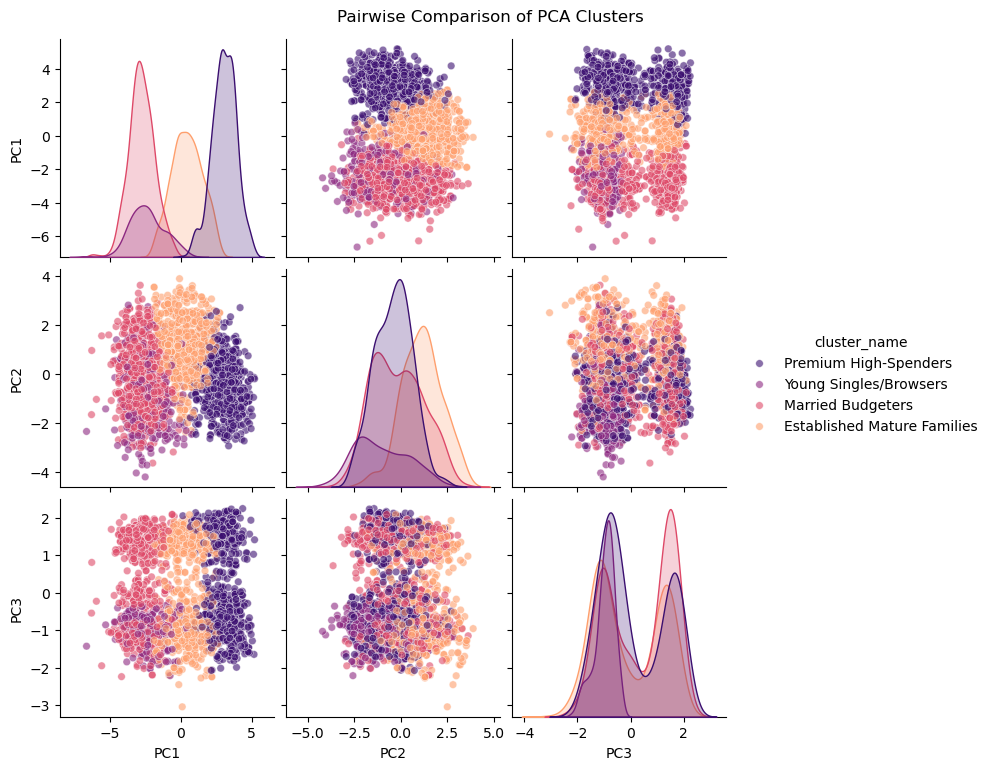

In [28]:
cols_to_plot = ['PC1', 'PC2', 'PC3', 'cluster_name']

cluster_names = {
    0: 'Married Budgeters',
    1: 'Premium High-Spenders',
    2: 'Young Singles/Browsers',
    3: 'Established Mature Families'
}

df_pca['cluster_name'] = df_pca['cluster'].map(cluster_names)
sns.pairplot(df_pca[cols_to_plot], 
             hue='cluster_name', 
             palette='magma', 
             diag_kind='kde', 
             plot_kws={'alpha': 0.6, 's': 30})

plt.suptitle('Pairwise Comparison of PCA Clusters', y=1.02)
plt.show()

In [ ]:
# Create a mapping dictionary
cluster_names = {
    0: 'Married Budgeters',
    1: 'Premium High-Spenders',
    2: 'Young Singles/Browsers',
    3: 'Established Mature Families'
}

# Apply the names
df_pca['cluster_name'] = df_pca['cluster'].map(cluster_names)

# Re-run your Plotly 3D scatter with the new names
import plotly.express as px
fig = px.scatter_3d(df_pca, x='PC1', y='PC2', z='PC3',
              color='cluster_name', 
# Use the names instead of numbers
              title='Customer Segments in 3D Space',
              opacity=0.8)
fig.show()

In [29]:
df_pca["cluster_name"].value_counts()

cluster_name
Premium High-Spenders          727
Married Budgeters              674
Established Mature Families    591
Young Singles/Browsers         245
Name: count, dtype: int64